<a href="https://colab.research.google.com/github/SriHarsha2698/Fruit_classifier/blob/main/Fruit_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install torch torchvision matplotlib scikit-learn pillow streamlit opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 78.3 MB/s eta 0:00:00


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from PIL import Image

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [4]:
!unzip dataset.zip

Archive:  dataset.zip
   creating: dataset/
   creating: dataset/test/
   creating: dataset/test/apple/
  inflating: dataset/test/apple/Image_20.jpg  
  inflating: dataset/test/apple/Image_22.jpg  
  inflating: dataset/test/apple/Image_32.jpg  
  inflating: dataset/test/apple/Image_35.jpg  
  inflating: dataset/test/apple/Image_37.jpg  
   creating: dataset/test/banana/
  inflating: dataset/test/banana/Image_20.jpg  
  inflating: dataset/test/banana/Image_30.jpg  
  inflating: dataset/test/banana/Image_32.jpg  
  inflating: dataset/test/banana/Image_39.jpg  
  inflating: dataset/test/banana/Image_40.png  
   creating: dataset/test/cherry/
  inflating: dataset/test/cherry/Image_36.jpg  
  inflating: dataset/test/cherry/Image_37.jpg  
  inflating: dataset/test/cherry/Image_38.jpg  
  inflating: dataset/test/cherry/Image_39.jpg  
  inflating: dataset/test/cherry/Image_40.jpg  
   creating: dataset/test/chickoo/
  inflating: dataset/test/chickoo/Image_36.jpg  
  inflating: dataset/test/chi

In [5]:
import os
os.listdir("dataset/train")

['mango',
 'cherry',
 'strawberry',
 'banana',
 'orange',
 'chickoo',
 'apple',
 'kiwi',
 'grapes']

In [6]:
!ls dataset

test  train  val


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [8]:
train_data = datasets.ImageFolder("dataset/train", transform=train_transform)
val_data   = datasets.ImageFolder("dataset/val", transform=test_transform)
test_data  = datasets.ImageFolder("dataset/test", transform=test_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16)
test_loader  = DataLoader(test_data, batch_size=16)

classes = train_data.classes
print(classes)

['apple', 'banana', 'cherry', 'chickoo', 'grapes', 'kiwi', 'mango', 'orange', 'strawberry']


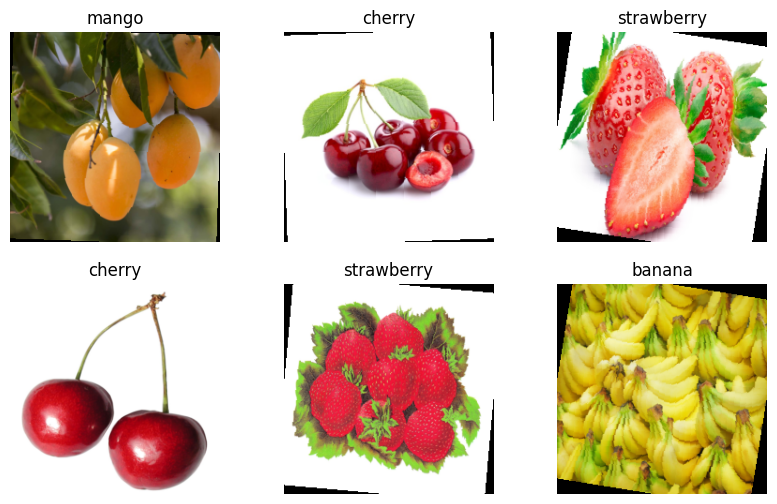

In [9]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(weights="DEFAULT")
model.fc = nn.Linear(model.fc.in_features, 9)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [12]:
for epoch in range(10):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 23.9067
Epoch 2, Loss: 6.0727
Epoch 3, Loss: 2.5208
Epoch 4, Loss: 1.3327
Epoch 5, Loss: 1.3394
Epoch 6, Loss: 0.6040
Epoch 7, Loss: 0.6047
Epoch 8, Loss: 0.3641
Epoch 9, Loss: 0.4143
Epoch 10, Loss: 0.3978


In [13]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Accuracy:", 100 * correct / total)

Accuracy: 84.44444444444444


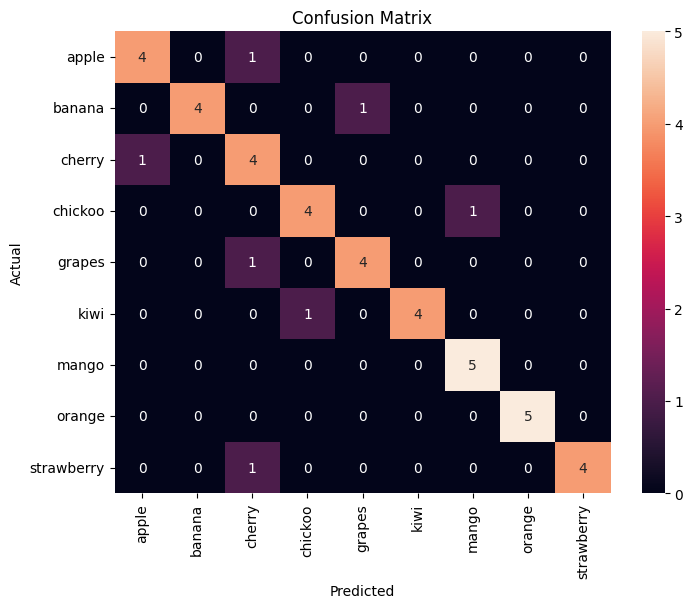

In [14]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
torch.save(model.state_dict(), "tesco_fruit_model.pth")

In [16]:
from google.colab import files
uploaded = files.upload()

Saving Black-Grapes-1.webp to Black-Grapes-1.webp


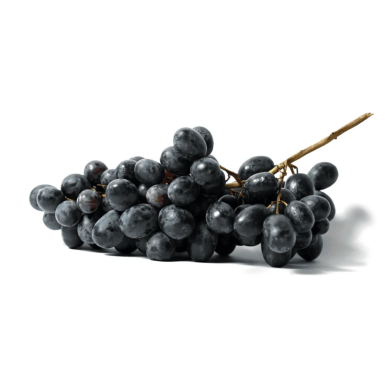

In [17]:
from PIL import Image

img = Image.open(list(uploaded.keys())[0]).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

In [18]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

x = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(x)
    pred = output.argmax(1).item()

print("Prediction:", classes[pred])

Prediction: grapes
